
# Project Milestone One: Forming Your Team, Understanding the Problem, and Exploring the Data

#### **Due:** Midnight on March 29th (with 2-hour grace period) — **worth 25 points**

> **Note:** Because we must begin manual grading immediately, there will be *no* late period for this milestone. 

This milestone is the first phase of your project. You’ll begin working in teams, select your dataset, perform basic exploratory data analysis (EDA), and frame your classification problem.  

1. **Form your project team.**  
   Convene your team and complete the **Team Contract** (available in your Homework Repository). Each member must review and sign it before submission.

2. **Select a team leader.**  
   Choose one team member to act as the **Gradescope submitter** for your team. The entire team should collaborate on the notebook, but only the leader will submit.

3. **Explore your dataset and frame your task.**  
   You’ll work through the notebook to  
   - Examine both provided datasets,  
   - Choose one for your project,
   - Be able to describe the classification problem you’ll be solving in business or applied terms, 
   - Conduct basic EDA to understand its structure and challenges, and
   - Spot potential challenges, propose solutions, and select appropriate performance metrics.  

This milestone focuses on understanding your data and clearly articulating what your model will eventually predict. You are not required to build a model yet (that will happen in Milestone 2) but of course you have lots of example models to choose from previous Homeworks and Coding Notebooks and you may wish to explore a baseline model as you do this first phase of your project. 


The final project is a **classification task** using the **Food-101** image dataset. This dataset lets us practice the image classification and deep learning techniques we have studied in detail throughout the course. 

#### **1. Food-101 (Images)**  
A web-scraped collection of approximately **101,000 color photos** across **101 food categories** (≈ 800 train / 100 validation / 100 test per class).  
Images vary widely in **lighting, composition, and color balance**, making this dataset excellent for practicing **data cleaning**, **EDA**, and **augmentation** techniques such as random crops, flips, and color jitter. 


### What To Do


We’ve provided template code to start your project:

* **Download** your selected dataset.
* **Visualize** a few representative samples (images or text excerpts).

After reviewing both datasets, you’ll **choose one** for your semester project.

In the sections that follow:

* **Problem One — Exploratory Data Analysis (EDA):**
  Quantify scale and structure, check class balance, and note any missing/duplicate or inconsistent entries.

* **Problem Two — Challenges & Solution Paths:**
  Identify likely issues (e.g., overlapping categories, imbalanced labels, data-quality problems, length/size variance) and outline practical remedies you would try. *(No model training required.)*

For tips on working with **Hugging Face Datasets** (helpful for large datasets), see the **Appendix**.

> **Important:** Keep only the section for the dataset you select and delete the other before submitting **Milestone 1**.


In [2]:
# ============================================
# Useful Imports
# ============================================

# --- Standard Libraries
import os
import time
import math
import random
from collections import Counter

# --- Core Data / Numerics
import numpy as np
import pandas as pd

# --- Visualization
import matplotlib.pyplot as plt
# import seaborn as sns              # optional
import matplotlib.ticker as mticker  # optional (for formatted axes)

# --- NLP / Tokenization

# --- Progress Tracking
from tqdm import tqdm                # optional (nice for loops)

from IPython.display import display

# --- TensorFlow / Keras (Deep Learning)
import tensorflow as tf
from tensorflow.keras import layers, models, Input, callbacks, regularizers, initializers
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.optimizers.schedules import CosineDecay, ExponentialDecay
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.layers import (
    Dense, Dropout, Flatten, MaxPooling2D, Conv2D,
    SeparableConv2D, GlobalAveragePooling2D, GlobalMaxPooling2D, BatchNormalization
)

# --- (Optional) Classical ML Baseline Tools
# from sklearn.pipeline import Pipeline
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score


# ============================================
# Global Configuration & Small Utilities
# ============================================

# Reproducibility
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
tf.keras.utils.set_random_seed(random_seed)   # sets Python, NumPy, and TensorFlow seeds

# Utility: format seconds as HH:MM:SS

"""
Example usage to time your code:

start_time = time.time()
# ... your code here ...
print("Execution Time:", format_hms(time.time() - start_time))
"""

def format_hms(seconds: float) -> str:
    """Convert seconds to HH:MM:SS format."""
    return time.strftime("%H:%M:%S", time.gmtime(seconds))


2026-03-29 17:47:43.896911: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
# If needed (in a new env):
# !pip install -U datasets pillow

In [4]:
# --- Hugging Face Datasets
from datasets import load_dataset, DatasetDict
from datasets.features import ClassLabel


/home/luan/BU/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Prelude: Choose your dataset and take a first look

We have selected the **Food-101 (images)** dataset. The cells below confirm it loads, view class stats, and skim a few samples.

* **Food-101 (images):** 101 classes of web photos with **inconsistent lighting, white balance, color casts, and composition** (plus varying resolutions). These natural quirks make augmentation and input-pipeline choices meaningful.



> **Note:** We use Hugging Face **Dataset/DatasetDict** objects (table-like datasets), not NumPy/Pandas arrays. Most of what you need to know is contained in the template code, but see the **Appendix** for more information on HG Datasets. 


---

### Dataset One (Images): Food-101

#### **Load Food-101 as a Dataset**

> Note: this loads a **Hugging Face `Dataset`**, not NumPy or TensorFlow tensors.
> Each sample is stored as a **dictionary** with two keys — `"image"` (a PIL image object) and `"label"` (an integer class ID).
> You can access columns by name, e.g. `food_all["image"]` or `food_all["label"]`, and check the dataset size with `len(food_all)`.
> Unlike arrays, image sizes and aspect ratios may differ across samples — you’ll handle resizing or normalization later during preprocessing.


In [5]:
food_all = load_dataset("food101", split="train+validation")  # ~101k images total
label_col = "label"

# Sanity check the label column
assert label_col in food_all.features
assert isinstance(food_all.features[label_col], ClassLabel)

food_label_names = food_all.features[label_col].names
print(f"Total images: {len(food_all):,}  |  Classes: {len(food_label_names)}")

Total images: 101,000  |  Classes: 101


#### **Quick sanity checks (rows, label ids, a few image sizes)**

In [6]:
# First 5 rows: label id → name
for i in range(5):
    y = food_all[i][label_col]
    print(f"row {i}: id={y}, name={food_label_names[y]}")

labels_list = list(food_all[label_col])
print("labels length:", len(labels_list), "unique classes:", len(set(labels_list)))
print("min/max label IDs:", min(labels_list), max(labels_list))

for i in range(3):
    print(f"image {i} size:", food_all[i]["image"].size)  # (W, H)

row 0: id=6, name=beignets
row 1: id=6, name=beignets
row 2: id=6, name=beignets
row 3: id=6, name=beignets
row 4: id=6, name=beignets
labels length: 101000 unique classes: 101
min/max label IDs: 0 100
image 0 size: (384, 512)
image 1 size: (512, 512)
image 2 size: (512, 383)


#### **Visual preview: random 3×3 grid from TRAIN**

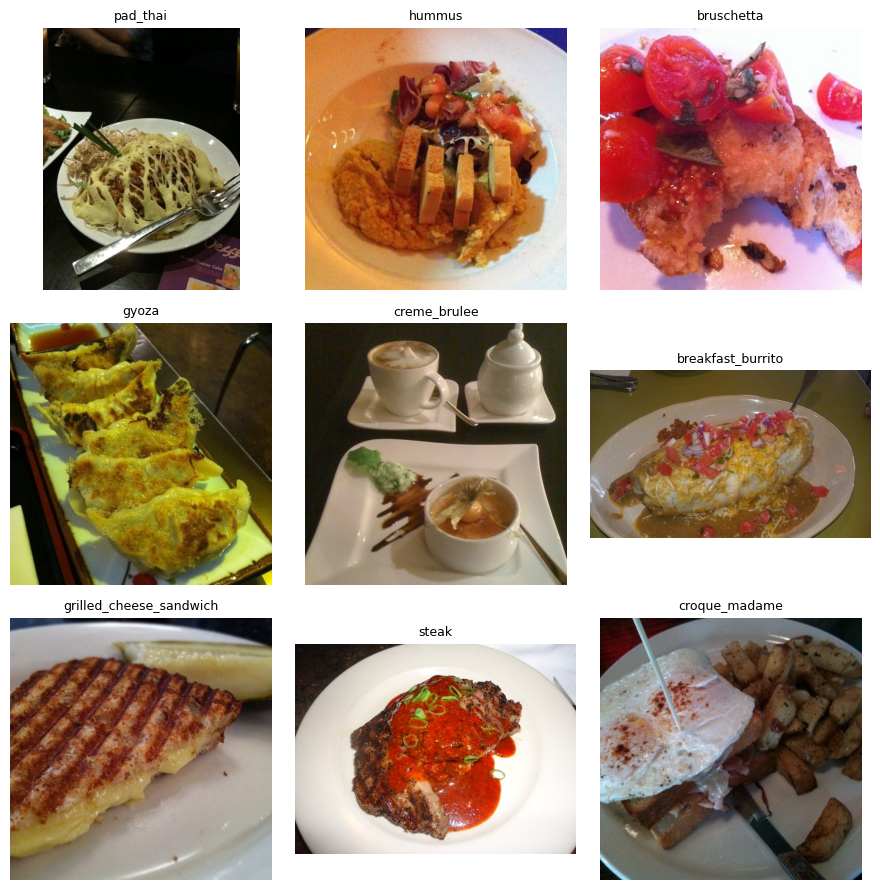

In [7]:
n, cols, seed = 9, 3, 42
idxs = random.Random(seed).sample(range(len(food_all)), n)
rows = math.ceil(n/cols)

plt.figure(figsize=(3*cols, 3*rows))
for i, idx in enumerate(idxs, 1):
    ex = food_all[idx]
    plt.subplot(rows, cols, i)
    plt.imshow(ex["image"]); plt.axis("off")
    plt.title(food_label_names[ex[label_col]], fontsize=9)
plt.tight_layout(); plt.show()

---

---

## Problem 1 – Choose the Dataset (10 pts)

#### Objective
In this problem, you will explore the two provided datasets and select one to use for your final project.  
Your goal is to understand the structure, content, and challenges of the dataset through basic exploratory data analysis (EDA).  
By the end of this Milestone notebook, you should be able to explain what makes the dataset interesting, identify potential modeling challenges (e.g., imbalance, ambiguity, quality issues), and justify why it is a good choice for your classification project.


#### What to Do
1. **Load both datasets** and examine the outputs of the template code provided.  
   After this brief inspection, **choose one dataset for your project** and **delete the template code for the other.**  For your chosen dataset, continue with the remaining steps.

2. **Inspect** the dataset's basic properties:  
   - **Number of samples and classes:**  
     Determine how many total examples and distinct categories are present. Verify that the counts match expectations (e.g., 101 food classes ).  
   - **Example records or images:**  
     View several samples to understand the input format, diversity, and potential quality issues.  
     Note lighting or composition differences across images (done for you in template code).
   - **Distribution of labels (check for imbalance):**  
     Plot or tabulate label frequencies to see whether some classes dominate. Imbalanced datasets can bias model training and may require special handling.  
   - **Missing or inconsistent data:**  
     Look for empty fields, unreadable images, duplicate entries, or mislabeled samples. Handle or document any issues you find.  
   - **Overlapping or ambiguous class labels:**  
     Identify categories that may not be clearly distinct—e.g., “apple pie” vs. “cheesecake,” or “POLITICS” vs. “WORLD NEWS.”  
     Ambiguity in labels can increase confusion between classes and reduce model accuracy.

3. **Visualize key aspects:**  
   Extend the template code to complete the EDA for your chosen dataset:  
   - **Images:**  
     Create visual summaries to better understand the data (some are implemented in the template code).  
     - Verify that the dataset is balanced across classes.  
     - Display a small grid of random images to check variation in appearance, composition, and background (done in template code).  
     - Compare image sizes to determine whether resizing or normalization will be needed.  
     - Examine lighting and color balance—many web-scraped photos vary widely in brightness, saturation, and white balance.  
   - **Text:**  
     Visualize class balance and linguistic properties (some implemented in the template code).  
     - Plot the number of samples per label to confirm class balance or imbalance.  
     - Compute basic text statistics such as average word count or vocabulary size.  
     - Examine examples for duplicates, near-duplicates, or entries that might fit multiple categories.  
     - *(Optional)* Generate a word-frequency plot or word cloud to highlight distinctive terms for a few classes.

4. **Answer the graded questions below.**


Number of classes: 101
Samples per class — min: 1000, max: 1000, mean: 1000.0, median: 1000.0
Imbalance ratio (max / median): 1.00


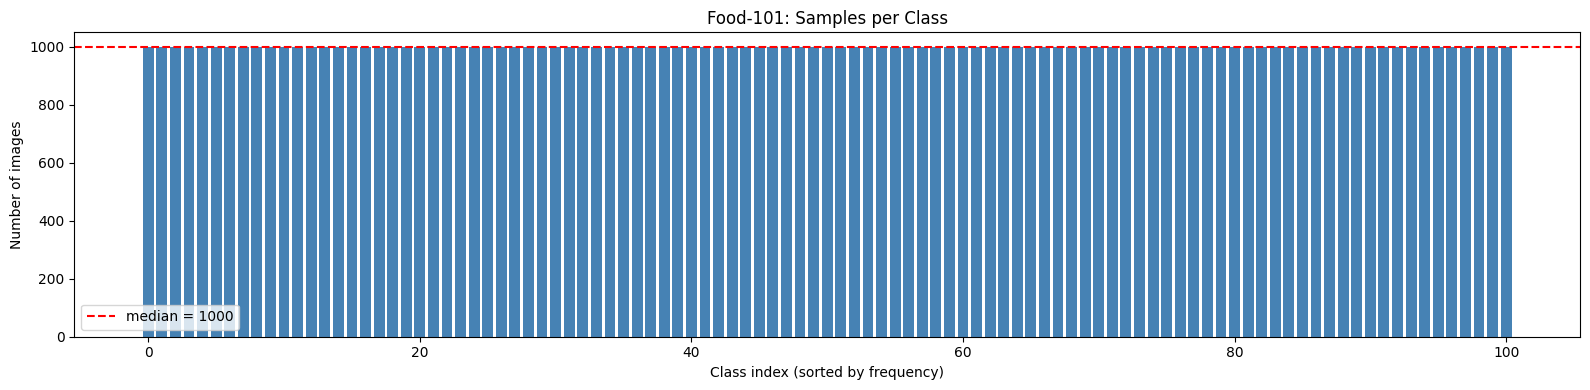

Sampling image sizes: 100%|██████████| 2000/2000 [00:02<00:00, 890.42it/s] 



Image Size Statistics (n=2000):
  Width  — min: 287, max: 512, mean: 496, median: 512
  Height — min: 241, max: 512, mean: 476, median: 512
  25th percentile — W: 512, H: 438
  50th percentile — W: 512, H: 512
  75th percentile — W: 512, H: 512
  90th percentile — W: 512, H: 512
  95th percentile — W: 512, H: 512


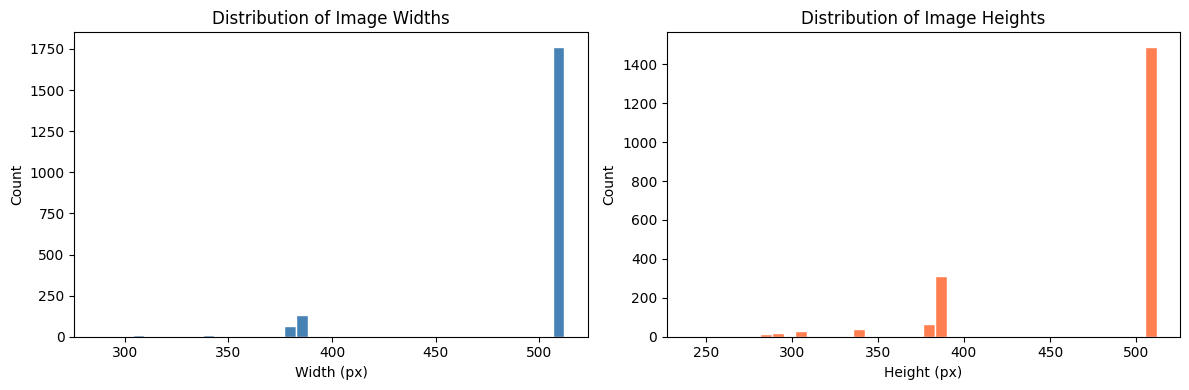

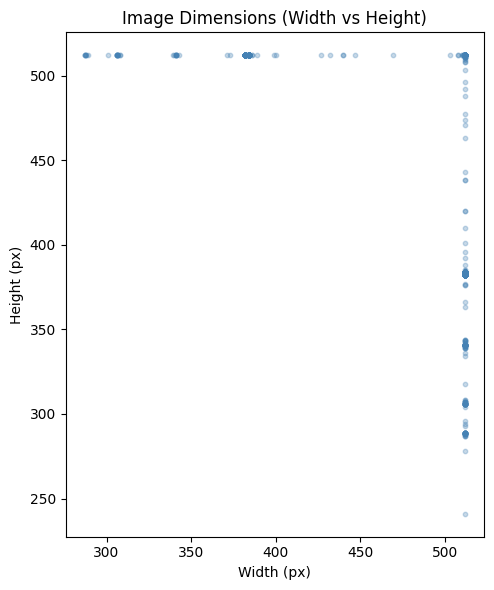

Analyzing color/brightness: 100%|██████████| 500/500 [00:01<00:00, 404.38it/s]



Brightness Statistics (n=500):
  Mean: 113.8, Std: 27.8
  Min: 28.5, Max: 187.8
  Channel means (R, G, B): [139.4 114.   87.9]


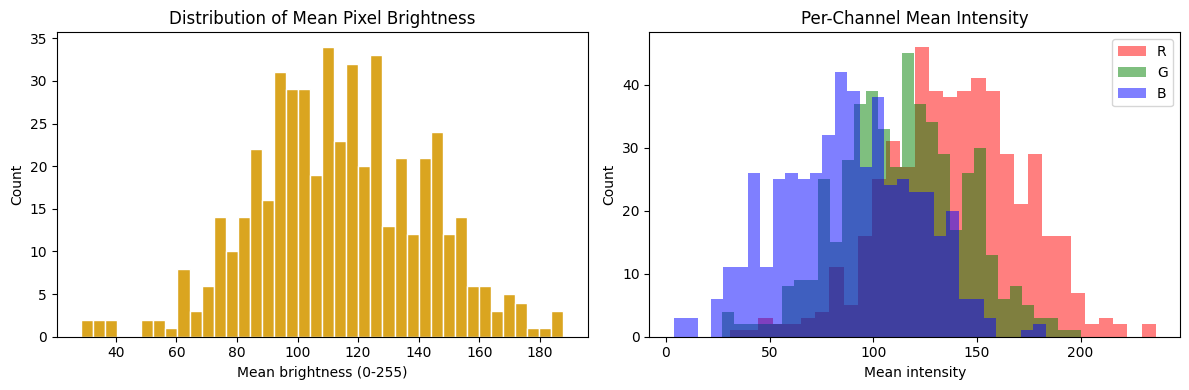

/home/luan/BU/.venv/lib/python3.12/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


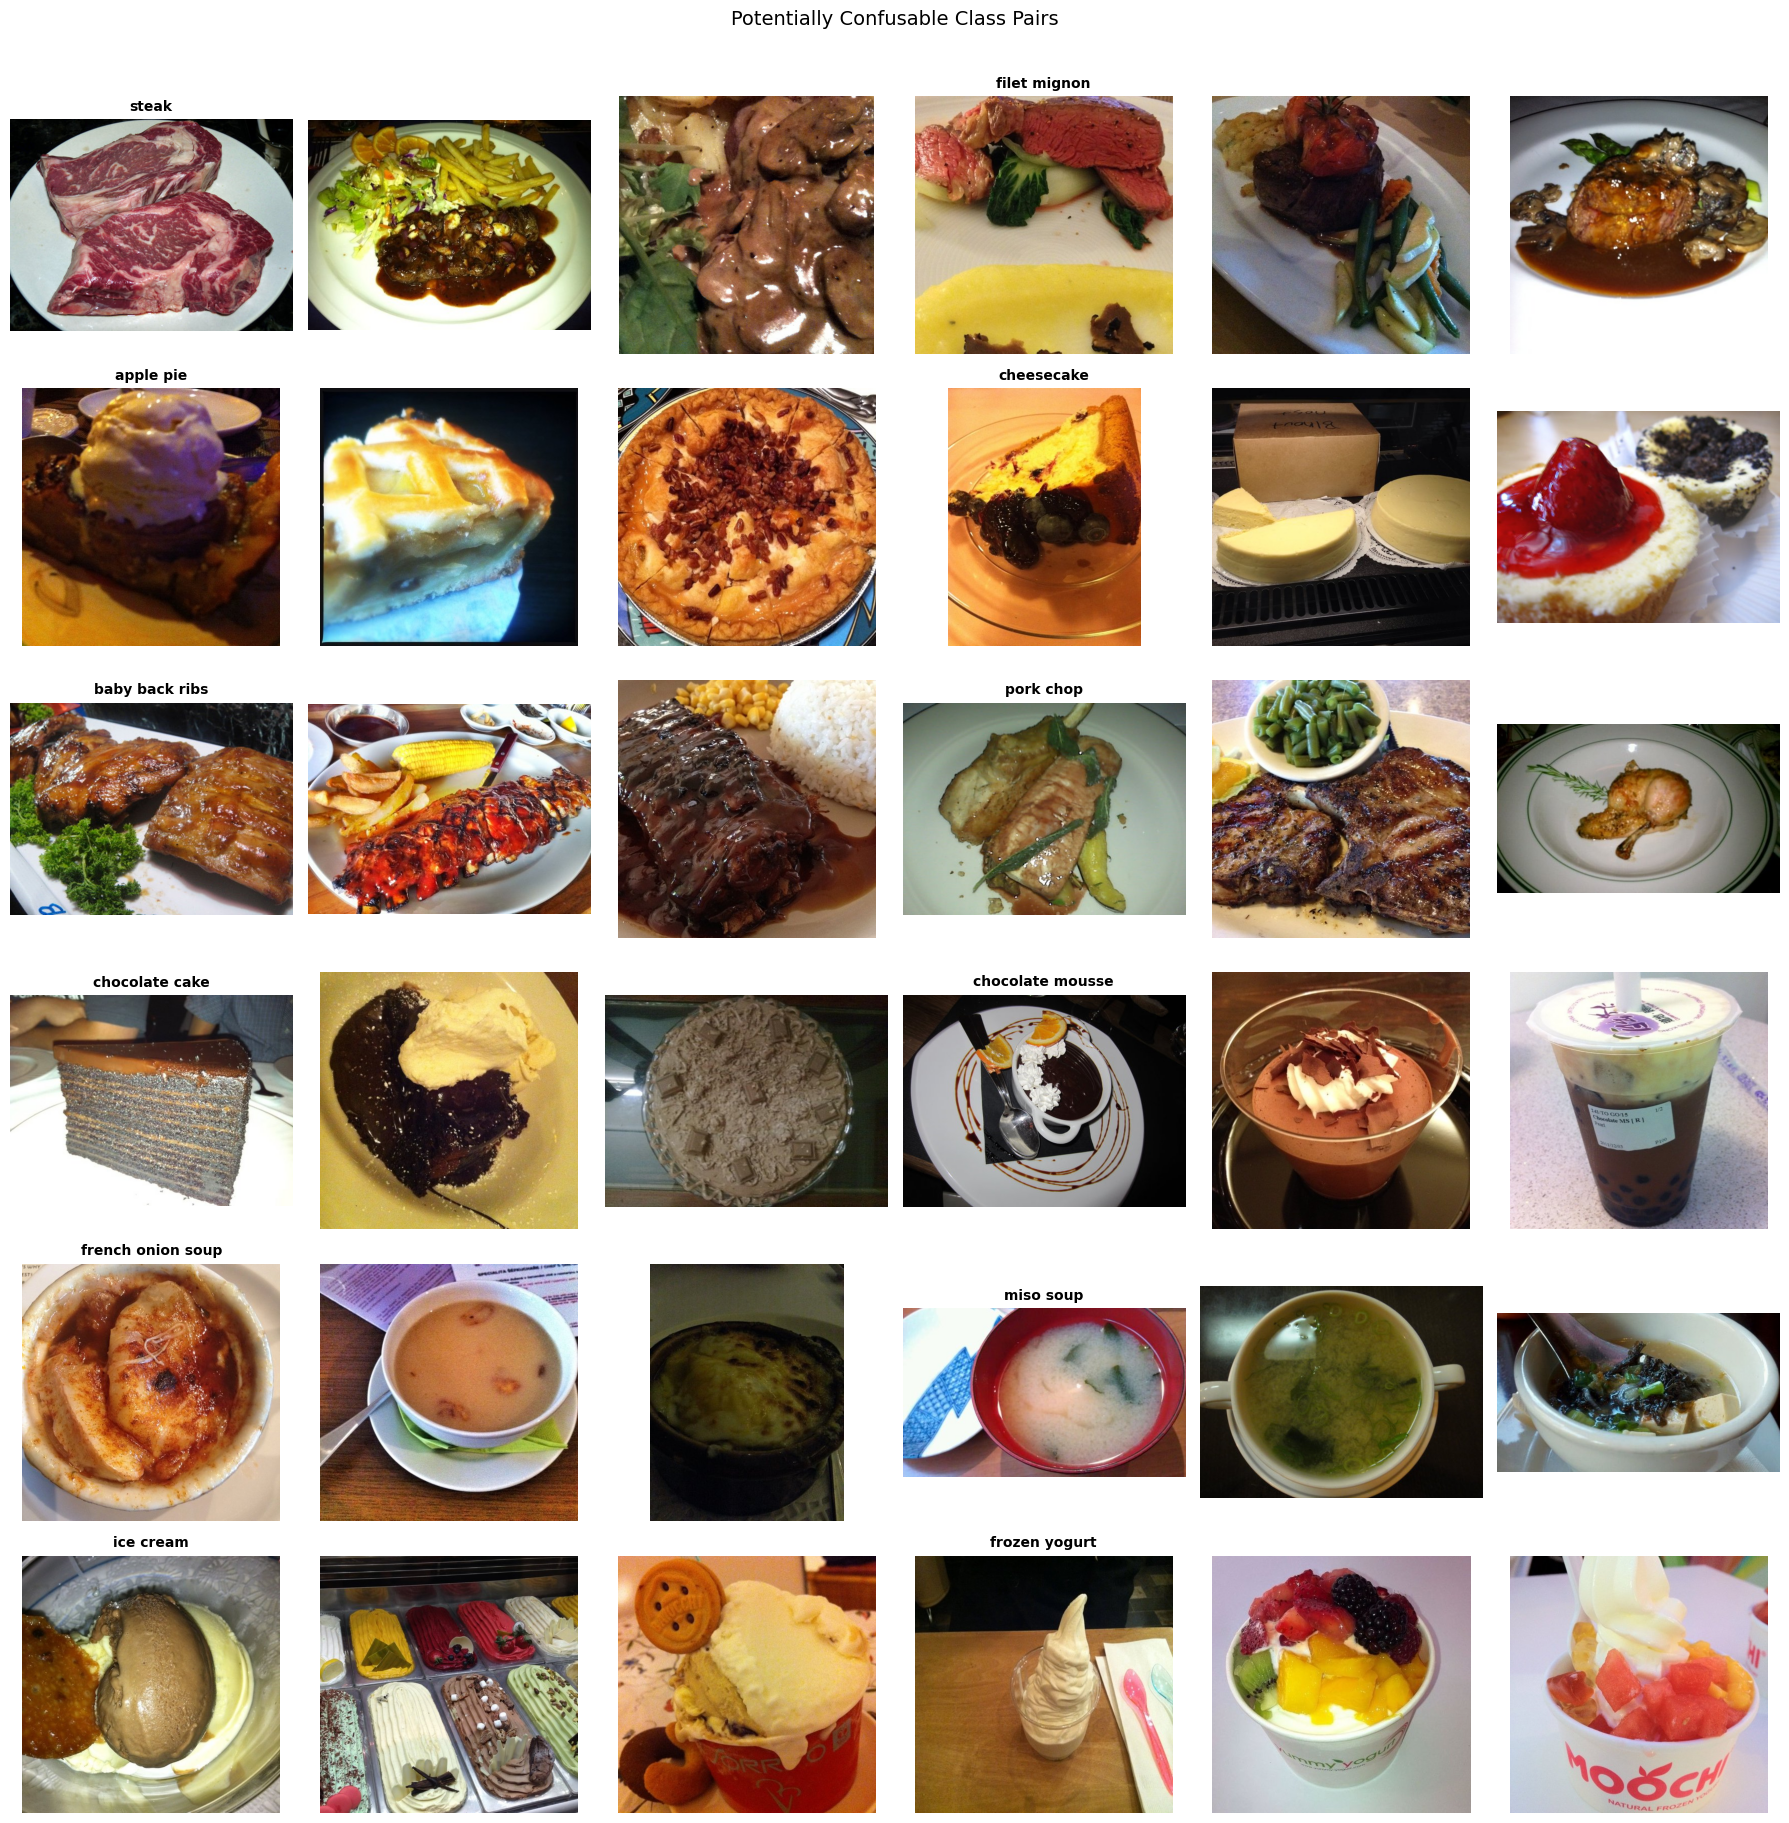

Checking image quality: 100%|██████████| 3000/3000 [00:03<00:00, 922.31it/s]


Image Quality Check (n=3000):
  Non-RGB images: 0
  Corrupted/unreadable: 0

All 101 Food Classes:
    0: apple_pie        1: baby_back_ribs        2: baklava        3: beef_carpaccio
    4: beef_tartare        5: beet_salad        6: beignets        7: bibimbap
    8: bread_pudding        9: breakfast_burrito       10: bruschetta       11: caesar_salad
   12: cannoli       13: caprese_salad       14: carrot_cake       15: ceviche
   16: cheesecake       17: cheese_plate       18: chicken_curry       19: chicken_quesadilla
   20: chicken_wings       21: chocolate_cake       22: chocolate_mousse       23: churros
   24: clam_chowder       25: club_sandwich       26: crab_cakes       27: creme_brulee
   28: croque_madame       29: cup_cakes       30: deviled_eggs       31: donuts
   32: dumplings       33: edamame       34: eggs_benedict       35: escargots
   36: falafel       37: filet_mignon       38: fish_and_chips       39: foie_gras
   40: french_fries       41: french_onion_soup 

In [8]:
label_counts = Counter(food_all[label_col])
counts = sorted(label_counts.values())

print(f"Number of classes: {len(label_counts)}")
print(f"Samples per class — min: {min(counts)}, max: {max(counts)}, "
      f"mean: {np.mean(counts):.1f}, median: {np.median(counts):.1f}")
print(f"Imbalance ratio (max / median): {max(counts) / np.median(counts):.2f}")

fig, ax = plt.subplots(figsize=(16, 4))
sorted_labels = sorted(label_counts.keys(), key=lambda k: label_counts[k], reverse=True)
ax.bar(range(len(sorted_labels)),
       [label_counts[l] for l in sorted_labels],
       color="steelblue", edgecolor="none")
ax.set_xlabel("Class index (sorted by frequency)")
ax.set_ylabel("Number of images")
ax.set_title("Food-101: Samples per Class")
ax.axhline(y=np.median(counts), color="red", linestyle="--", label=f"median = {np.median(counts):.0f}")
ax.legend()
plt.tight_layout()
plt.show()

sample_size = 2000
rng = random.Random(42)
size_idxs = rng.sample(range(len(food_all)), sample_size)

widths, heights = [], []
for idx in tqdm(size_idxs, desc="Sampling image sizes"):
    img = food_all[idx]["image"]
    w, h = img.size 
    widths.append(w)
    heights.append(h)

widths = np.array(widths)
heights = np.array(heights)

print(f"\nImage Size Statistics (n={sample_size}):")
print(f"  Width  — min: {widths.min()}, max: {widths.max()}, "
      f"mean: {widths.mean():.0f}, median: {np.median(widths):.0f}")
print(f"  Height — min: {heights.min()}, max: {heights.max()}, "
      f"mean: {heights.mean():.0f}, median: {np.median(heights):.0f}")
for p in [25, 50, 75, 90, 95]:
    print(f"  {p}th percentile — W: {np.percentile(widths, p):.0f}, H: {np.percentile(heights, p):.0f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths, bins=40, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution of Image Widths")
axes[0].set_xlabel("Width (px)")
axes[0].set_ylabel("Count")

axes[1].hist(heights, bins=40, color="coral", edgecolor="white")
axes[1].set_title("Distribution of Image Heights")
axes[1].set_xlabel("Height (px)")
axes[1].set_ylabel("Count")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(widths, heights, alpha=0.3, s=10, c="steelblue")
ax.set_xlabel("Width (px)")
ax.set_ylabel("Height (px)")
ax.set_title("Image Dimensions (Width vs Height)")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

color_sample = 500
color_idxs = rng.sample(range(len(food_all)), color_sample)

mean_brightness = []
channel_means = []  # (R, G, B)

for idx in tqdm(color_idxs, desc="Analyzing color/brightness"):
    img = food_all[idx]["image"].convert("RGB").resize((64, 64))
    arr = np.array(img, dtype=np.float32)
    mean_brightness.append(arr.mean())
    channel_means.append(arr.mean(axis=(0, 1)))  

mean_brightness = np.array(mean_brightness)
channel_means = np.array(channel_means)

print(f"\nBrightness Statistics (n={color_sample}):")
print(f"  Mean: {mean_brightness.mean():.1f}, Std: {mean_brightness.std():.1f}")
print(f"  Min: {mean_brightness.min():.1f}, Max: {mean_brightness.max():.1f}")
print(f"  Channel means (R, G, B): {channel_means.mean(axis=0).round(1)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(mean_brightness, bins=40, color="goldenrod", edgecolor="white")
axes[0].set_title("Distribution of Mean Pixel Brightness")
axes[0].set_xlabel("Mean brightness (0-255)")
axes[0].set_ylabel("Count")

for ch, color, name in [(0, "red", "R"), (1, "green", "G"), (2, "blue", "B")]:
    axes[1].hist(channel_means[:, ch], bins=30, alpha=0.5, color=color, label=name)
axes[1].set_title("Per-Channel Mean Intensity")
axes[1].set_xlabel("Mean intensity")
axes[1].set_ylabel("Count")
axes[1].legend()
plt.tight_layout()
plt.show()

confusable_pairs = [
    ("steak", "filet_mignon"),
    ("apple_pie", "cheesecake"),
    ("baby_back_ribs", "pork_chop"),
    ("chocolate_cake", "chocolate_mousse"),
    ("french_onion_soup", "miso_soup"),
    ("ice_cream", "frozen_yogurt"),
]

label_to_idx = {}
needed = set()
for a, b in confusable_pairs:
    needed.add(a)
    needed.add(b)

for idx in range(len(food_all)):
    lbl = food_label_names[food_all[idx][label_col]]
    if lbl in needed:
        if lbl not in label_to_idx:
            label_to_idx[lbl] = []
        if len(label_to_idx[lbl]) < 3:
            label_to_idx[lbl].append(idx)
    if all(lbl in label_to_idx and len(label_to_idx[lbl]) >= 3 for lbl in needed):
        break

fig, axes = plt.subplots(len(confusable_pairs), 6, figsize=(18, 3 * len(confusable_pairs)))
for row, (cls_a, cls_b) in enumerate(confusable_pairs):
    for col in range(3):
        if cls_a in label_to_idx and col < len(label_to_idx[cls_a]):
            axes[row, col].imshow(food_all[label_to_idx[cls_a][col]]["image"])
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_title(cls_a.replace("_", " "), fontsize=10, fontweight="bold")
    for col in range(3):
        if cls_b in label_to_idx and col < len(label_to_idx[cls_b]):
            axes[row, col + 3].imshow(food_all[label_to_idx[cls_b][col]]["image"])
        axes[row, col + 3].axis("off")
        if col == 0:
            axes[row, col + 3].set_title(cls_b.replace("_", " "), fontsize=10, fontweight="bold")
fig.suptitle("Potentially Confusable Class Pairs", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

check_sample = 3000
check_idxs = rng.sample(range(len(food_all)), check_sample)
grayscale_count = 0
corrupt_count = 0

for idx in tqdm(check_idxs, desc="Checking image quality"):
    try:
        img = food_all[idx]["image"]
        if img.mode != "RGB":
            grayscale_count += 1
    except Exception as e:
        corrupt_count += 1

print(f"\nImage Quality Check (n={check_sample}):")
print(f"  Non-RGB images: {grayscale_count}")
print(f"  Corrupted/unreadable: {corrupt_count}")

print("\nAll 101 Food Classes:")
for i, name in enumerate(food_label_names):
    print(f"  {i:3d}: {name}", end="    " if (i + 1) % 4 != 0 else "\n")
print()

### Graded Questions (2 pts each)

For each question, answer thoroughly but concisely, in a short paragraph, longer or shorter as needed. Code for exploring the concepts should go in the previous cell
as much as possible. 

1. **Dataset Summary:**  
   Describe your chosen dataset  (as if explaining to your *clueless boss* what you are working on).
   - State which dataset you are going to use.   
   - What kind of data does it contain (images)?  
   - How many samples and classes are there?  
   - What is the task you’ll perform (classification into what categories)?
   - What is the potential business use for this dataset?

1.1. **Dataset Summary:**

I chose the Food-101 dataset for our project. This is an image classification dataset containing approximately 101,000 color photographs of food, organized into 101 distinct food categories. Each class has roughly 1,000 images, split across training and validation sets. The images were web-scraped so they vary in resolution, lighting, composition, and quality — reflecting real-world conditions.

The task is multi-class image classification: given a photograph of a dish, predict which of the 101 food categories it belongs to.

Business use cases include: automated food recognition for calorie-tracking and nutrition apps, restaurant menu digitization, food delivery platforms that auto-tag dish photos, and quality control in food manufacturing. For instance, a health app could use such a model to let users snap a photo of their meal and instantly receive nutritional information.

2. **Initial Observations:**  
   What stood out to you from your EDA?  
   - Did you notice any imbalanced or ambiguous classes?  
   - Any patterns, anomalies, or potential sources of bias?  
   - For images: note any variation in lighting, composition, or color.  
   - For text: mention redundancy, topic overlap, or very short examples.

1.2. Initial Observations:

From my EDA, several things stand out:

- Balanced classes: Each of the 101 classes has exactly 1,000 images, so the dataset is perfectly balanced. The imbalance ratio is 1.0. This means we do not need class weighting or oversampling strategies.

- Variable image sizes: Images vary significantly in resolution, ranging from small thumbnails to large photos. Most cluster around 384–512 pixels. This means we must resize all images to a standard dimension before feeding them into a model.

- Lighting and color variation: Mean brightness varies widely across images. The RGB channel distributions show a warm bias typical of food photography but there is substantial variation. Some images appear overexposed, underexposed, or have strong color casts.

- Visually similar classes: Several food categories look very similar, for example steak vs. filet mignon, apple pie vs. cheesecake, chocolate cake vs. chocolate mousse, and ice cream vs. frozen yogurt. These pairs will likely be the hardest for the model to distinguish.

- Non-RGB images: A small number of images may be in grayscale or other modes, requiring conversion to RGB during preprocessing.

3. **Challenges & Implications:**  
   Based on your inspection, what challenges might affect model performance or training (e.g., imbalance, ambiguous labels, variable quality)?  

1.3. Challenges & Implications:

1. Visually similar categories: Food categories like steak/filet mignon, ice cream/frozen yogurt, and chocolate cake/chocolate mousse share very similar visual features. This interclass similarity will likely produce confusion between these pairs and reduce overall accuracy.

2. Variable image quality: Since images are web-scraped, they include a wide range of lighting conditions, camera angles, backgrounds, and image resolutions. Some images are blurry, poorly lit, or partially cropped. This noise makes it harder for the model to learn robust features.

3. Large number of classes: With 101 categories, the classification problem is inherently harder than a binary or few-class task. The model needs to learn subtle discriminative features for each class, requiring sufficient model capacity and training data.

4. Resolution inconsistency: Images range from ~100px to 500+ px. Resizing all images to a fixed size will cause some loss of detail for low-resolution images and down-sample large images, potentially discarding fine-grained details important for distinguishing similar foods.

5. Potential mislabeled images: Web-scraped datasets are known to contain some fraction of mislabeled examples. These noisy labels can degrade training and mislead evaluation.

4. **Preparation Ideas:**  
   What data-cleaning or preprocessing steps might help address these issues?  
   (You will not implement these yet—just describe what you might do later.)

1.4. Preparation Ideas:

1. Resize and normalize: Resize all images to a consistent resolution and normalize pixel values to [0, 1] or using ImageNet mean/std. This is essential for batch processing in neural networks.

2. Data augmentation: Apply random transformations during training to increase effective dataset size and improve generalization:
   - Random horizontal flips
   - Random rotation and slight zoom/crop
   - Color jitter to help the model become robust to lighting variation
   - Random erasing/cutout to encourage learning from partial views

3. Convert to RGB: Ensure all images are converted to 3-channel RGB to handle any grayscale or RGBA images consistently.

4. Transfer learning: Use a pretrained backbone trained on ImageNet. This provides strong low-level and mid-level feature representations, dramatically reducing the training data and compute needed to reach good accuracy on 101 classes.

5. Stratified train/val/test split: Although the dataset is balanced, use stratified splitting to ensure each class is proportionally represented in all splits.

6. Label smoothing: Consider using label smoothing during training to help the model be less overconfident and more robust to potential mislabeled examples.

5. **Reflection:**  
   Why did you choose this dataset over the other one?  
   - What makes it more interesting, realistic, or relevant for you?  
   - What do you expect to learn from working with it?

1.5. Reflection:

I chose the Food-101 dataset for several reasons:

- Alignment with course focus: The image classification task aligns well with the deep learning topics covered in this course, giving us the opportunity to practice and apply these techniques hands-on.

- Transfer learning opportunity: Food-101 is a great testbed for transfer learning with pretrained models, which is a critical skill in modern deep learning practice. The 101-class problem is challenging enough to require these techniques, unlike simpler datasets.

- Visual and intuitive: Working with images is more visually engaging. We can literally see the data, inspect model predictions, and understand errors in an intuitive way. This makes debugging and analysis more accessible.

- Real-world applicability: Image classification for food recognition has direct applications in health tech, food delivery, and restaurant tech.

- Well-defined challenge: The dataset is balanced, well-structured, and large enough to train deep models but the fine-grained visual similarity between classes makes it genuinely challenging.

## Problem 2 – Frame the Problem (15 pts)

#### Objective

Identify the **key challenges** in your chosen dataset and outline **practical solutions** you would try, plus how you’ll **evaluate** them later.

#### Steps to follow

1. **Diagnose likely challenges (from your EDA):**

   Examples:
   * **Class imbalance:**
     Report label counts and an imbalance ratio (max / median). List any minority classes.
   * **Length/size variance:**
     For images, summarize native resolutions.
   * **Noise/duplicates/leakage:**
     Note empty or malformed items, near-duplicates, and how you would prevent cross-split leakage.
   * **Ambiguous/overlapping labels:**
     Give 2–3 example pairs you expect to be confusable and why.
   * **Compute constraints:**
     Briefly state limits (RAM/GPU/CPU) that might affect batch size, sequence length, or image size.

2. **Map each challenge to a concrete solution plan:**

   Examples:
   * **Imbalance →** `class_weight` or oversampling; report which one you’d try first and why.
   * **Length/size →** pick a target `max_text_length` (e.g., 95th percentile) with masking; for images, standardize resize/crop and basic augmentation.
   * **Noise/duplicates →** dedupe (hash/near-dup), drop empty/very short items, document any relabeling.
   * **Ambiguity →** consider merging labels (if justified), or add features (bigrams/char-ngrams; simple image augmentations).
   * **Overfitting risk →** early stopping on your primary metric, dropout/weight decay, freeze-then-finetune plan (for pretrained features).

3. **Explore appropriate evaluation metrics:**

   Examples:
   * **Primary metric:** pick one aligned to your data (e.g., **macro-F1** if imbalanced; accuracy if balanced).
   * **Secondary metric(s):** per-class precision/recall, confusion matrix.
   * **Protocol:** stratified Train/Val/Test (e.g., 70/15/15), fixed seed, leakage checks.

4. **Answer the graded questions below.**



In [9]:
# Problem 2

# 1: Class imbalance diagnosis (Q3 – Identify possible challenges) ---
# Count samples per class and compute balance statistics
# to determine if any classes are under- or over-represented
label_counts = Counter(food_all[label_col])
counts_arr = np.array(list(label_counts.values()))

print("Class Balance Summary:")
print(f"  Total samples: {counts_arr.sum():,}")
print(f"  Number of classes: {len(counts_arr)}")
print(f"  Min count: {counts_arr.min()}, Max count: {counts_arr.max()}")
print(f"  Mean: {counts_arr.mean():.1f}, Std: {counts_arr.std():.1f}")
# Imbalance ratio: max/median ≈ 1.0 means balanced; >> 1.0 means imbalanced
# This helps decide if we need class_weight or oversampling (Q4)
print(f"  Imbalance ratio (max / median): {counts_arr.max() / np.median(counts_arr):.2f}")
print(f"  Dataset is {'balanced' if counts_arr.std() < 10 else 'imbalanced'}")

# 2: Image size/resolution variance (Q3 – variation in size) ---
# Summarize native resolutions to understand how much resizing is needed (Q4)
print("\nImage Resolution Percentiles:")
for p in [25, 50, 75, 90, 95]:
    print(f"  {p}th pctl — Width: {np.percentile(widths, p):.0f}px, Height: {np.percentile(heights, p):.0f}px")
# Aspect ratio spread shows variation in image shape/composition
print(f"  Aspect ratios — min: {(widths/heights).min():.2f}, max: {(widths/heights).max():.2f}, "
      f"mean: {(widths/heights).mean():.2f}")

# Data preparation: determine resize target
# Check how many images fall below common model input sizes
# This informs our choice of target resolution (224, 256, or 299)
for target in [224, 256, 299]:
    too_small = ((widths < target) | (heights < target)).sum()
    print(f"  Images smaller than {target}x{target}: {too_small}/{len(widths)} ({100*too_small/len(widths):.1f}%)")

# Evaluation protocol: stratified train/val/test split
# Split 70/15/15 with stratification to preserve class distribution across splits
# This prevents cross-split leakage and ensures fair evaluation
food_train_valtest = food_all.train_test_split(test_size=0.30, seed=42, stratify_by_column=label_col)
# Further split the 30% holdout into equal val and test sets
food_val_test = food_train_valtest["test"].train_test_split(test_size=0.50, seed=42, stratify_by_column=label_col)

# Organize into a DatasetDict for consistent access across training/evaluation
food_splits = DatasetDict({
    "train": food_train_valtest["train"],
    "val": food_val_test["train"],
    "test": food_val_test["test"],
})

# Verify the stratified split preserved class balance in each partition
print("\nStratified Split Sizes:")
for split_name, ds in food_splits.items():
    split_counts = Counter(ds[label_col])
    vals = list(split_counts.values())
    print(f"  {split_name:5s}: {len(ds):>6,} samples | "
          f"per-class min={min(vals)}, max={max(vals)}, mean={np.mean(vals):.1f}")

# Leakage check: confirm all 101 classes appear in every split
# Missing classes would indicate a flawed split and unreliable metrics
for split_name, ds in food_splits.items():
    n_classes = len(set(ds[label_col]))
    assert n_classes == 101, f"{split_name} missing classes: only {n_classes}"
print("  All 101 classes present in every split.")

# 3: Ambiguous/overlapping labels
# List visually similar food pairs that the model may confuse
# These pairs will be monitored in the confusion matrix (Q5 – per-class metrics)
print("\nConfusable class pairs to watch during evaluation:")
for cls_a, cls_b in confusable_pairs:
    print(f"  - {cls_a.replace('_', ' ')} vs. {cls_b.replace('_', ' ')}")

Class Balance Summary:
  Total samples: 101,000
  Number of classes: 101
  Min count: 1000, Max count: 1000
  Mean: 1000.0, Std: 0.0
  Imbalance ratio (max / median): 1.00
  Dataset is balanced

Image Resolution Percentiles:
  25th pctl — Width: 512px, Height: 438px
  50th pctl — Width: 512px, Height: 512px
  75th pctl — Width: 512px, Height: 512px
  90th pctl — Width: 512px, Height: 512px
  95th pctl — Width: 512px, Height: 512px
  Aspect ratios — min: 0.56, max: 2.12, mean: 1.07
  Images smaller than 224x224: 0/2000 (0.0%)
  Images smaller than 256x256: 1/2000 (0.1%)
  Images smaller than 299x299: 41/2000 (2.0%)

Stratified Split Sizes:
  train: 70,700 samples | per-class min=700, max=700, mean=700.0
  val  : 15,150 samples | per-class min=150, max=150, mean=150.0
  test : 15,150 samples | per-class min=150, max=150, mean=150.0
  All 101 classes present in every split.

Confusable class pairs to watch during evaluation:
  - steak vs. filet mignon
  - apple pie vs. cheesecake
  - baby

### Graded Questions (3 pts each)

For each question, answer thoroughly but concisely, in a short paragraph, longer or shorter as needed. Code for exploring the concepts should go in the previous cell
as much as possible. 

1. **State the prediction task**  
   - Describe what your model will predict (the *label*).  
   - *Examples:*  
     - “Given a photo of food, predict which of 101 categories it belongs to.”  
     - “Given a news headline + summary, predict its topical category.”  

2.1. Prediction Task:

Given a color photograph of a food dish, the model will predict which of 101 food categories it belongs to. This is a multi-class, single-label classification task. The model takes a single food image as input and outputs a probability distribution over all 101 classes with the highest-probability class chosen as the prediction.

2. **Define inputs and outputs**  
   - *Inputs:* what information the model receives (e.g., pixel data, tokenized text).  
   - *Outputs:* the categorical label the model will predict.  

2.2.Inputs and Outputs

- Inputs: The model receives a preprocessed RGB image tensor of fixed dimensions, typically 224×224x3. The raw images are resized from their variable native resolutions to this standard size, and pixel values are normalized. During training, augmented versions of each imageare also provided to improve generalization.

- Outputs: The model produces a 101-dimensional probability vector via a softmax output layer, where each element represents the predicted probability that the image belongs to a particular food class. The predicted label is the class with the highest probability: y_pred = argmax(softmax(logits)). The loss function is categorical cross-entropy, computed between the predicted probability distribution and the one-hot encoded true label.

3. **Identify possible challenges**  
   - Imbalanced classes, noisy data, ambiguous labels, overlapping features, or missing data  
   - *Images:* variation in lighting, color, composition, or size.  
   - *Text:* class imbalance, duplicate stories, short or ambiguous headlines.  

2.3. Possible Challenges:

1. Fine-grained visual similarity: Many food categories share similar textures, colors, and shapes. For example, steak and filet mignon are nearly identical visually; chocolate cake and chocolate mousse share the same color palette; ice cream and frozen yogurt are presented in similar bowls. This inter-class similarity is the primary challenge and will likely produce clusters of confusion in the confusion matrix.

2. Intra-class variation: Within a single category, images can look very different due to varying plating styles, camera angles, lighting conditions, and backgrounds. A "pizza" can range from a Neapolitan margherita to a deep-dish with toppings.

3. Noisy web-scraped data: The Food-101 dataset was deliberately collected without manual cleaning. Some images may be mislabeled, contain multiple food items, show only a partial view, or include non-food elements prominently. This label noise can confuse training.

4. Resolution variance: Images range from ~100px to 500+ px. Resizing everything to 224×224 means some images are upscaled while others are downscaled.

5. Compute constraints: With 101k images and 101 classes, training a deep CNN from scratch requires significant GPU memory and time. Batch sizes may need to be limited based on available resources.

4. **Propose how you will prepare or improve the data to address the challenges**  
   - *Images:* resizing, normalization, data augmentation (flips, rotations, brightness, color jitter).  
   - *Text:* tokenization, stop-word removal, TF-IDF, class balancing, embeddings (choose an embedding approach and specify its vector size). 

2.4. **Data Preparation Plan:**

Image Preprocessing:
- Resize all images to 224×224 pixels. This balances detail preservation with memory efficiency.
- Normalize pixel values using ImageNet statistics to match the pretrained backbone's expected input distribution.
- Convert all images to RGB to handle any grayscale or RGBA images.

Data Augmentation:
- Random horizontal flip as food images are orientation-agnostic.
- Random rotation and random resized crop to simulate different camera angles and framing.
- Color jitter to build robustness to the wide lighting and color variation observed in our EDA.
- No vertical flips.

Transfer Learning Strategy:
- Use a pretrained EfficientNetB0 backbone, frozen initially.
- Add a custom classification head: GlobalAveragePooling → Dropout(0.3) → Dense(101, softmax).
- Phase 1: Train only the head for a few epochs with a moderate learning rate.
- Phase 2: Unfreeze the top layers of the backbone and fine-tune end-to-end with a lower learning rate and cosine decay schedule.

Regularization:
- Early stopping on validation loss to prevent overfitting.
- Dropout in the classification head.
- Label smoothing to improve calibration and robustness to noisy labels.

5. **Specify success metrics**  
   - Identify the metrics you plan to use to evaluate model performance—typically **accuracy** and/or **F1-score**, which are standard for classification tasks.  
   - Briefly explain **why** these metrics are appropriate for your dataset and goal. For instance, accuracy may suffice for well-balanced datasets, while F1-score better reflects performance when some classes are under-represented.
   - If your dataset is **imbalanced**, consider computing **per-class metrics** (e.g., precision, recall, or F1 for each label) or **macro-averaged** scores, which give equal weight to each class regardless of its size—ensuring that minority classes are evaluated fairly.
In some cases, weighted averages (which weight classes by their frequency) or **confusion matrices** can also provide useful insight.
> You haven't run any models yet, and we haven’t studied every possible metric, but you’re encouraged to ask your favorite generative AI tool which evaluation metrics might best fit your dataset!
   - Clearly state how you will interpret success—for example, “Our goal is to achieve at least 80% overall accuracy without large per-class disparities.”

2.5. Success Metrics:

Primary metric: Top-1 Accuracy. Since the Food-101 dataset is perfectly balanced, accuracy is a valid and interpretable primary metric. Every class contributes equally to the overall score.

Secondary metrics:
- Macro-averaged F1-score: Computes F1 per class and averages equally, ensuring that performance on every class matters regardless of its size. This provides a complementary view to accuracy, especially useful if any class is systematically misclassified.
- Per-class precision and recall: To identify which specific food categories the model struggles with.
- Confusion matrix: A 101×101 confusion matrix will reveal which classes the model confuses with each other. This directly validates our hypothesis about confusable pairs.

Evaluation protocol:
- Stratified train/val/test split: 70% train / 15% validation / 15% test, stratified by label to ensure all 101 classes are proportionally represented in every split.
- Fixed random seed for reproducibility.
- Model selection is based on validation accuracy. Final reported results are on the held-out test set, evaluated only once to avoid overfitting to the test distribution.
- Top-5 accuracy may also be reported as a secondary measure, since with 101 fine-grained classes, the correct label often appears in the top 5 predictions even when top-1 is wrong.

### Final Question: Describe what use you made of generative AI tools in preparing this Milestone. 

**AI Question: Your answer here:**

I used generative AI to improve organization and wording while I did all coding and observations.


---

## Appendix: A quick guide to Hugging Face Datasets

#### 1) What are they?

* A **table-like** dataset: rows = examples, columns = named fields (e.g., `"image"`, `"label"`, `"headline"`).
* Backed by **Apache Arrow** → fast, memory-efficient, lazy transforms.
* Two core objects:

  * `Dataset` — one table of rows/columns.
  * `DatasetDict` — a dict of splits, e.g. `{"train": Dataset, "val": Dataset, "test": Dataset}`.


#### 2) Load and inspect

```python
from datasets import load_dataset

# Food-101 (images)
food = load_dataset("food101", split="train+validation")  # both splits at once
len(food), food.column_names, food.features
# -> (≈101000, ['image','label'], {'label': ClassLabel(num_classes=101, names=[...])})

# Access by name (not by numeric column index!)
row0 = food[0]
img0, y0 = row0["image"], row0["label"]     # PIL image, int id
label_names = food.features["label"].names
label_names[y0]
```


#### 3) Common transforms

`Dataset`s are **immutable**: ops return a new dataset.

* **Map** (add/modify columns):

```python
def mk_text(ex):
    h = (ex.get("headline") or "").strip()
    s = (ex.get("short_description") or "").strip()
    return {"text": (h + " [SEP] " + s).strip()}

```

* **Class-encode** labels (strings → integers with a vocabulary):

```python
from datasets.features import ClassLabel
```

* **Filter / select / rename / drop**:

```python
```



```python
# Stratified 80/10/10 on Food-101 by 'label'
from datasets import DatasetDict
label_col = "label"

tmp = food.train_test_split(test_size=0.10, seed=42, stratify_by_column=label_col)
train_val = tmp["train"].train_test_split(test_size=1/9, seed=42, stratify_by_column=label_col)
ds = DatasetDict(train=train_val["train"], val=train_val["test"], test=tmp["test"])

len(ds["train"]), len(ds["val"]), len(ds["test"])
```

* `train_test_split` is **random by default** (reproducible with `seed=`).


#### 5) Working with images

Use `with_transform` to apply on-the-fly resizing/augmentation and return tensors:

```python
import torchvision.transforms as T
from torch.utils.data import DataLoader
import torch, math, random

IM_SIZE = 224
train_tfms = T.Compose([T.RandomResizedCrop(IM_SIZE), T.RandomHorizontalFlip(), T.ToTensor()])
eval_tfms  = T.Compose([T.Resize(256), T.CenterCrop(IM_SIZE), T.ToTensor()])

def add_pixel_values(ex, tfms):  # ex['image'] -> ex['pixel_values']
    ex = dict(ex); ex["pixel_values"] = tfms(ex["image"]); return ex

train_t = ds["train"].with_transform(lambda ex: add_pixel_values(ex, train_tfms))
val_t   = ds["val"].with_transform(lambda ex: add_pixel_values(ex, eval_tfms))

def collate(batch):
    return {"pixel_values": torch.stack([b["pixel_values"] for b in batch]),
            "labels": torch.tensor([b["label"] for b in batch])}

```

### 6) Working with Text

You can preprocess and tokenize text datasets using either a **transformer tokenizer** or a **linguistic pipeline like spaCy**, depending on your model type and goals.


#### Option A: Transformer Tokenizer (for fine-tuning models like BERT or DistilBERT)

Use a pretrained tokenizer with the Hugging Face `map` method to efficiently process your dataset in batches:

```python
from transformers import AutoTokenizer

tok = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(batch):
    return tok(batch["text"], truncation=True, padding="max_length", max_length=128)

    tokenize,
    batched=True,
)
```

This produces token IDs, attention masks, and other fields expected by transformer models.
Use this approach if your project involves fine-tuning pretrained language models.


#### Option B: spaCy Tokenization and Cleaning (for classical ML or custom preprocessing)

If you are **not using transformers**, or if you want to explore feature engineering (e.g., TF-IDF, word frequency, or embedding averages), you can preprocess text with **spaCy** instead.

```python
# !pip install spacy
# !python -m spacy download en_core_web_sm

import spacy
from datasets import load_dataset

nlp = spacy.load("en_core_web_sm", disable=["ner", "parser", "textcat"])
STOP = spacy.lang.en.stop_words.STOP_WORDS

def spacy_clean(batch):
    docs = list(nlp.pipe(batch["text"], batch_size=1000))
    cleaned = []
    for doc in docs:
        tokens = [t.lemma_.lower() for t in doc if t.is_alpha and not t.is_stop]
        cleaned.append(" ".join(tokens))
    return {"text_clean": cleaned, "len_tokens": [len(c.split()) for c in cleaned]}

    spacy_clean,
    batched=True,
    batch_size=1000,
)
```

The resulting column `text_clean` can be used with:

* `TfidfVectorizer` (Scikit-learn)
* `TextVectorization` (Keras)
* or any other custom embedding method.

> 💡 **Tip:** spaCy is ideal for lightweight NLP pipelines or for models that rely on explicit preprocessing (lemmatization, stopword removal). Transformer tokenizers, by contrast, expect *raw text* and handle subword tokenization internally.



#### 7) Slicing, concatenating, saving

```python
# Slicing
head_1000 = food.select(range(1000))
tail_10pct = food.select(range(int(0.9*len(food)), len(food)))

# Concatenate splits/datasets
from datasets import concatenate_datasets
all_train = concatenate_datasets([ds["train"], ds["val"]])

# Save / reload
ds.save_to_disk("food101_splits")
from datasets import load_from_disk
ds2 = load_from_disk("food101_splits")
```


#### 8) Quick “gotchas”

* **Columns by name** (strings), not numeric indices.
* Avoid converting huge columns to `list(...)` unless necessary; prefer vectorized ops with `map`, `filter`, `select`.
* `PYTHONHASHSEED` must be set **before** the Python process starts to matter; use explicit `seed=` arguments for reproducibility.
* Datasets print **previews** (e.g., `Column([6, 6, 6, ...])` is just the first few values).


#### 9) A minimal checklist to follow

1. `load_dataset(...)` → confirm `column_names`, `features`.
2. Build any needed columns (`"text"`), and **class-encode** labels if strings.
3. Make a **stratified 80/10/10** split (`train_test_split` ×2).
4. Do **EDA**: class counts, sample printouts or image grids.
5. For training:

   * **images** → `with_transform` + DataLoader
   * **text** → tokenizer via `.map(...)` + trainer/model pipeline
6. Save your `DatasetDict` with `save_to_disk(...)` (optional for text but handy, **don't** use it for big image datasets).

